In [1]:
import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)
import matplotlib.pyplot as plt
#plt.style.use("seaborn-whitegrid")
import seaborn as sns
import scipy

In [2]:
from google.colab import files
uploaded = files.upload()

Saving Egy-COVID-19.csv to Egy-COVID-19.csv


In [3]:
df = pd.read_csv("Egy-COVID-19.csv")
df.head(1)


,date,new_confirmed,new_deaths,new_recovered,new_pos_to_neg,active_pos,cases_in_hospital,total_confirmed,total_deaths,total_recovered,total_pos_to_neg,lockdown,lockdown_duration
0,3/1/2020,1,0,0,0,1,1,2,0,1,1,No,0


In [4]:
#check data size
df.shape

(85, 13)

In [5]:
#count the missing data
df.isnull().sum()


,0
date,0
new_confirmed,0
new_deaths,0
new_recovered,0
new_pos_to_neg,0
active_pos,0
cases_in_hospital,0
total_confirmed,0
total_deaths,0
total_recovered,0


In [6]:
print("Duplicates:", df.duplicated().sum())

Duplicates: 0


In [7]:
## Convert the 'date' from object to datetime format
df['date']=pd.to_datetime(df['date'])
#df.head(5)

In [8]:
#check if lockdown_duration > 0 then lockdown 'YES' else 'NO'
df['lockdown'] = np.where(df['lockdown_duration'] > 0, 'Yes', 'No')
#df.head()

In [9]:
#add new column to calculate death rate
df['deathrate']=(df['total_deaths']/df['total_confirmed'])*100
#df.head()

In [10]:
#round to two decimal places
df['deathrate'] = df['deathrate'].round(2)
#df.head(5)

In [11]:
# Convert 'lockdown' to category
df['lockdown'] = df['lockdown'].astype('category')


In [12]:
# Save the cleaned data to a new CSV file
df.to_csv('Egy-COVID-19_Cleaned.csv', index=False)

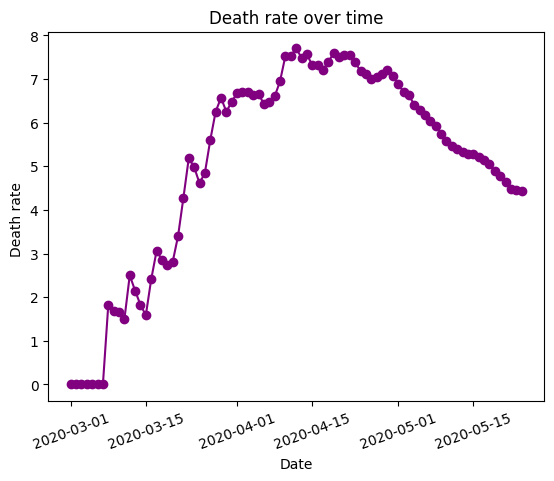

In [34]:

plt.plot(df['date'], df['deathrate'], color='purple', marker='o', linestyle='-')
plt.title('Death rate over time')
plt.xlabel('Date')
plt.ylabel('Death rate ')
plt.xticks(rotation=20)
plt.show()

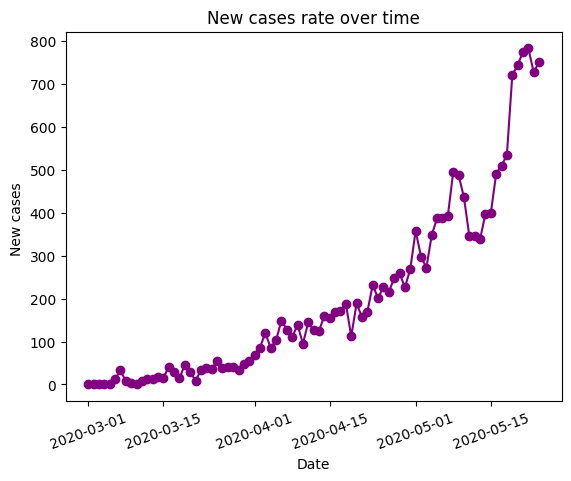

In [14]:
plt.plot(df['date'], df['new_confirmed'], color='purple', marker='o', linestyle='-')
plt.title('New cases rate over time')
plt.xlabel('Date')
plt.ylabel('New cases ')
plt.xticks(rotation=20)
plt.show()

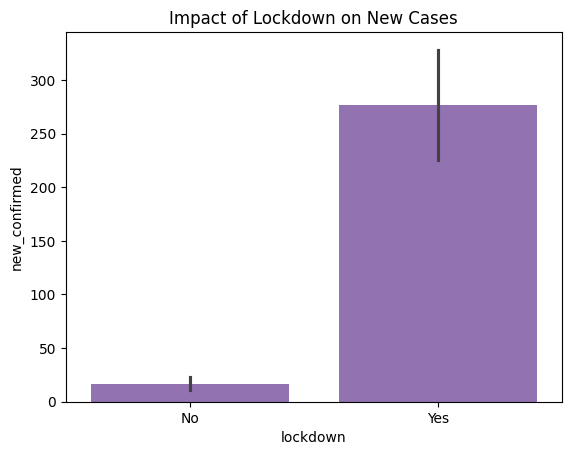

In [33]:
sns.color_palette()
base_color = sns.color_palette()[4]
sns.barplot(data=df,x='lockdown', y='new_confirmed', color=base_color)
plt.title('Impact of Lockdown on New Cases')
plt.show()

/tmp/ipykernel_3581/2254690442.py:3: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  plt.boxplot([lockdowndata,nolockdowndata], labels=['lockdown', 'no lockdown'])


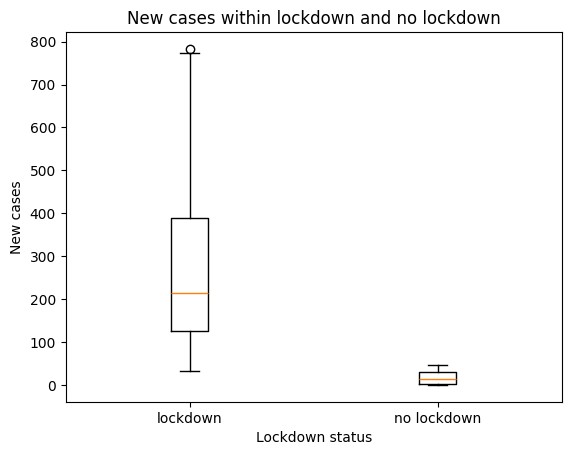

In [19]:

lockdowndata=df[df['lockdown'] == 'Yes']['new_confirmed']
nolockdowndata=df[df['lockdown'] == 'No']['new_confirmed']
plt.boxplot([lockdowndata,nolockdowndata], labels=['lockdown', 'no lockdown'])
plt.title('New cases within lockdown and no lockdown')
plt.xlabel('Lockdown status')
plt.ylabel('New cases')

plt.show()

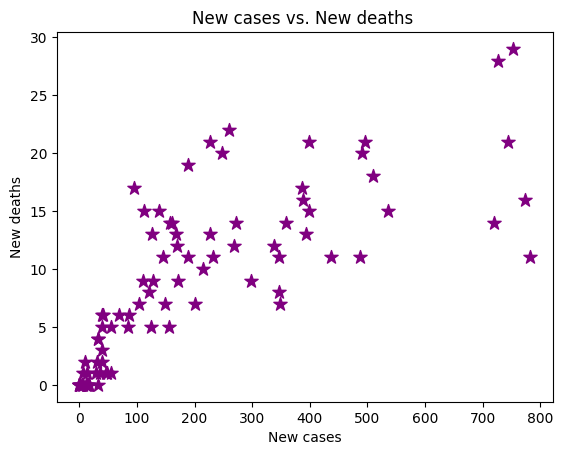

In [26]:
plt.scatter(df['new_confirmed'],df['new_deaths'], color='purple', s=100, marker='*')

plt.title('New cases vs. New deaths ')
plt.xlabel('New cases')
plt.ylabel('New deaths')

plt.show()